# Classifier work on the rig gathered digital dataset 

In [10]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import cv2
DATA_PATH="/home/dexter/Documents/data/simulation"

## Import data

In [11]:
df = pd.read_csv(DATA_PATH+"/recordings.csv")
df.head()

,image_id,x,y,z,speed,texture_id,marker_0_x,marker_0_y,marker_0_z,marker_1_x,...,marker_145_z,marker_146_x,marker_146_y,marker_146_z,marker_147_x,marker_147_y,marker_147_z,marker_148_x,marker_148_y,marker_148_z
0,0,0.3,0.3,0.220,0.0,0,0.220000,0.300001,0.215000,0.226917,...,0.135215,0.302959,0.294859,0.135208,0.297033,0.294865,0.135206,0.299993,0.299995,0.134995
1,1,0.3,0.3,0.219,0.0,0,0.219999,0.300001,0.213997,0.226917,...,0.134192,0.302961,0.294850,0.134182,0.297029,0.294861,0.134180,0.299987,0.299995,0.133979
2,2,0.3,0.3,0.218,0.0,0,0.219998,0.300001,0.212993,0.226917,...,0.133168,0.302964,0.294842,0.133156,0.297025,0.294857,0.133153,0.299981,0.299996,0.132961
3,3,0.3,0.3,0.217,0.0,0,0.219997,0.300002,0.211987,0.226918,...,0.132143,0.302967,0.294834,0.132131,0.297021,0.294852,0.132128,0.299975,0.299997,0.131943
4,4,0.3,0.3,0.216,0.0,0,0.219996,0.300002,0.210979,0.226918,...,0.131121,0.302970,0.294826,0.131107,0.297017,0.294847,0.131104,0.299970,0.299998,0.130926


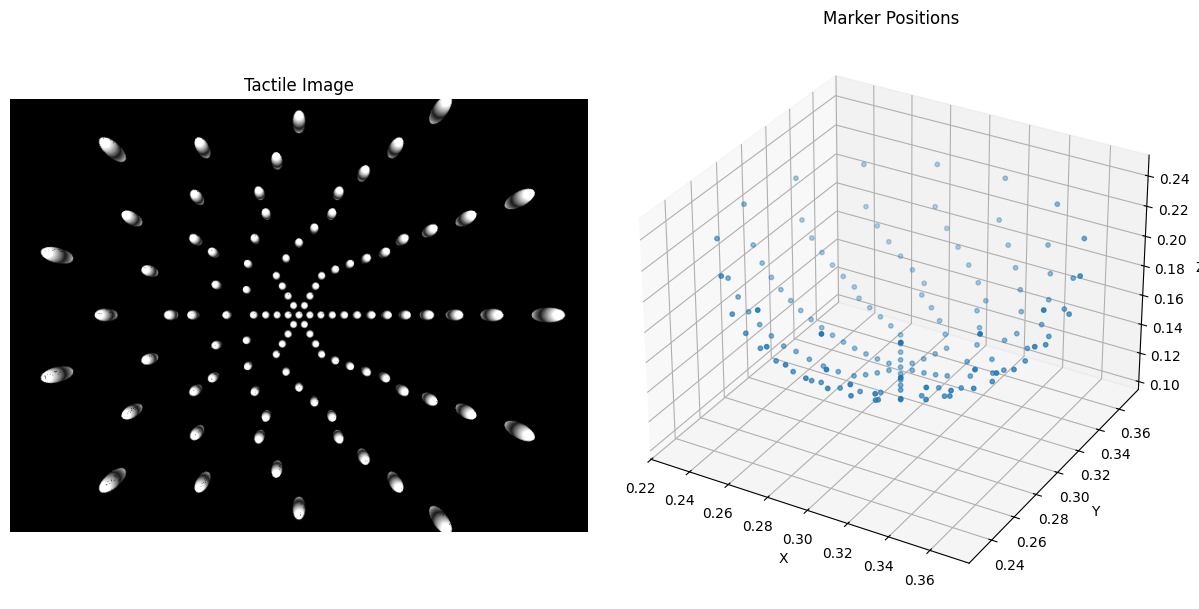

In [13]:
def get_entry_frame(image_id):
    row = df[df["image_id"] == image_id].iloc[0]

    # Find marker columns
    marker_cols = [
        col for col in df.columns 
        if col.startswith("marker_")
    ]

    # Extract marker values
    marker_values = row[marker_cols].values.astype(float)

    # Reshape into Nx3
    markers = marker_values.reshape(-1, 3)

    return markers

def plot_image_and_markers(image_path, markers):
    """
    Display tactile image alongside 3D marker positions.

    Args:
        image_path (str): Path to tactile image
        markers (np.ndarray): Nx3 array of marker positions
    """

    # Load image
    image = cv2.imread(image_path)

    # Convert BGR -> RGB for matplotlib
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    # Create figure with two subplots
    fig = plt.figure(figsize=(12, 6))

    # Image subplot
    ax1 = fig.add_subplot(1, 2, 1)
    ax1.imshow(image)
    ax1.set_title("Tactile Image")
    ax1.axis("off")

    # 3D marker subplot
    ax2 = fig.add_subplot(1, 2, 2, projection="3d")

    x = markers[:, 0]
    y = markers[:, 1]
    z = markers[:, 2]

    ax2.scatter(x, y, z, s=10)

    ax2.set_title("Marker Positions")
    ax2.set_xlabel("X")
    ax2.set_ylabel("Y")
    ax2.set_zlabel("Z")

    # Equal axis scaling
    max_range = np.ptp(markers, axis=0).max()

    mid_x = (x.max() + x.min()) / 2
    mid_y = (y.max() + y.min()) / 2
    mid_z = (z.max() + z.min()) / 2

    ax2.set_xlim(mid_x - max_range/2, mid_x + max_range/2)
    ax2.set_ylim(mid_y - max_range/2, mid_y + max_range/2)
    ax2.set_zlim(mid_z - max_range/2, mid_z + max_range/2)

    plt.tight_layout()
    plt.show()

image_id=1
markers = get_entry_frame(image_id)
plot_image_and_markers(
    DATA_PATH+f"/images/{image_id}.png",
    markers
)